# Analise e graficos - RQ05 a RQ08

Notebook de apoio a Lab01S03 (analise e visualizacao de dados). Gera os graficos
para as questoes de pesquisa validadas em `src/validate_sample.py`:

- **RQ05** - Sistemas populares sao escritos nas linguagens mais populares?
- **RQ06** - Sistemas populares possuem um alto percentual de issues fechadas?
- **RQ07** - Sistemas escritos em linguagens mais populares recebem mais
  contribuicao externa, lancam mais releases e sao atualizados com mais
  frequencia?
- **RQ08 (bonus)** - Licenca SPDX cruzada com estrelas e PRs aceitas.

Fonte dos dados: `data/repositorios_top1000.csv`. As constantes de linguagens
populares (Octoverse 2025) e a classificacao de licencas permissiva/copyleft
sao importadas diretamente de `src/validate_sample.py`, para manter os graficos
consistentes com a validacao textual ja existente.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from validate_sample import LINGUAGENS_POPULARES, classificar_licenca

CSV_PATH = PROJECT_ROOT / "data" / "repositorios_top1000.csv"
FIGURES_DIR = PROJECT_ROOT / "notebooks" / "figuras"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COR_POPULAR = "#2a6f97"
COR_OUTRA = "#a9c9dd"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv(CSV_PATH)
print(f"{len(df)} repositorios carregados de {CSV_PATH}")
df.head()

1000 repositorios carregados de C:\Users\Gabito\Documents\PUC\MEDICAO\Laboratorio-Experimentacao-de-Software\Laboratorio01\data\repositorios_top1000.csv


,repositorio,created_at,estrelas,linguagem_primaria,licenca,issues_total,issues_fechadas,percentual_issues_fechadas,pull_requests_aceitas,total_releases,ultima_atualizacao,dias_desde_ultima_atualizacao,ultimo_push,dias_desde_ultimo_push
0,codecrafters-io/build-your-own-x,2018-05-09T12:03:18Z,541169,Markdown,Sem licenca,948,677,0.7141,157,0,2026-08-19T15:06:46Z,0,2026-07-14T19:25:58Z,35
1,sindresorhus/awesome,2014-07-11T13:42:37Z,497712,Nao informada,CC0-1.0,368,352,0.9565,701,0,2026-08-19T15:09:14Z,0,2026-08-18T13:28:50Z,1
2,public-apis/public-apis,2016-03-20T23:49:42Z,465548,Python,MIT,940,910,0.9681,2147,0,2026-08-19T15:08:18Z,0,2026-08-18T19:20:39Z,0
3,freeCodeCamp/freeCodeCamp,2014-12-24T17:49:19Z,454327,TypeScript,BSD-3-Clause,22063,21899,0.9926,29115,0,2026-08-19T14:58:07Z,0,2026-08-19T10:40:53Z,0
4,EbookFoundation/free-programming-books,2013-10-11T06:50:37Z,394769,Python,CC-BY-4.0,1293,1255,0.9706,7423,0,2026-08-19T15:00:52Z,0,2026-08-18T14:16:15Z,1


## RQ05 - Linguagem primaria

Distribuicao das linguagens primarias dos 1000 repositorios, destacando as 5
linguagens do top 5 do GitHub Octoverse 2025 (`LINGUAGENS_POPULARES`).

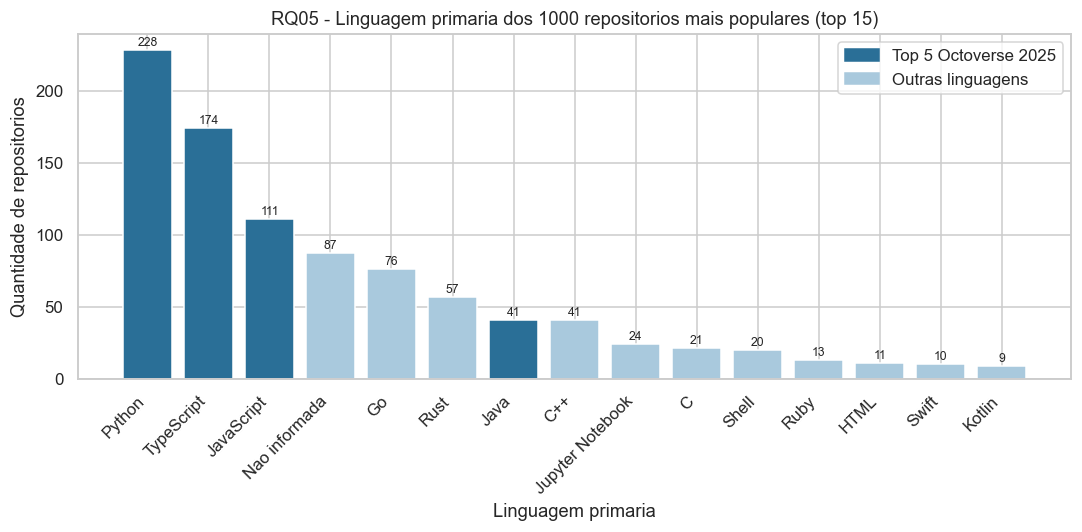

In [2]:
contagem_linguagens = df["linguagem_primaria"].value_counts()
top15 = contagem_linguagens.head(15)
cores = [COR_POPULAR if ling in LINGUAGENS_POPULARES else COR_OUTRA for ling in top15.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top15.index, top15.values, color=cores)
ax.set_title("RQ05 - Linguagem primaria dos 1000 repositorios mais populares (top 15)")
ax.set_xlabel("Linguagem primaria")
ax.set_ylabel("Quantidade de repositorios")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
for i, v in enumerate(top15.values):
    ax.text(i, v + 3, str(v), ha="center", fontsize=8)
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=COR_POPULAR, label="Top 5 Octoverse 2025"),
        plt.Rectangle((0, 0), 1, 1, color=COR_OUTRA, label="Outras linguagens"),
    ]
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rq05_top_linguagens.png")
plt.show()

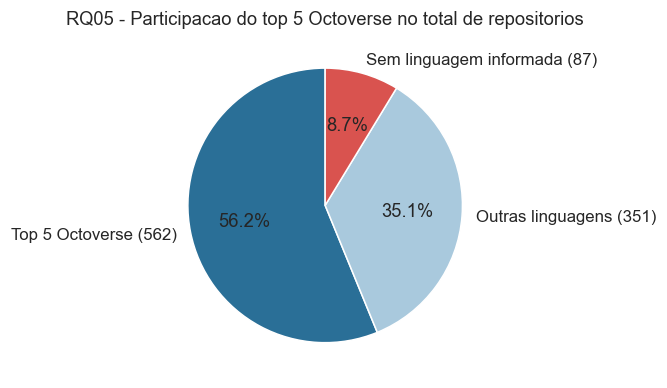

In [3]:
sem_linguagem = (df["linguagem_primaria"] == "Nao informada").sum()
no_top5 = df["linguagem_primaria"].isin(LINGUAGENS_POPULARES).sum()
fora_top5 = len(df) - no_top5 - sem_linguagem

fatias = [no_top5, fora_top5, sem_linguagem]
rotulos = [
    f"Top 5 Octoverse ({no_top5})",
    f"Outras linguagens ({fora_top5})",
    f"Sem linguagem informada ({sem_linguagem})",
]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    fatias,
    labels=rotulos,
    autopct="%1.1f%%",
    colors=[COR_POPULAR, COR_OUTRA, "#d9534f"],
    startangle=90,
)
ax.set_title("RQ05 - Participacao do top 5 Octoverse no total de repositorios")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rq05_participacao_top5.png")
plt.show()

## RQ06 - Percentual de issues fechadas

Distribuicao de `percentual_issues_fechadas` (repositorios com `issues_total = 0`
sao excluidos, pois nao tem percentual definido). O histograma mostra a forma
geral da distribuicao e o boxplot evidencia os outliers de 0% e 100%.

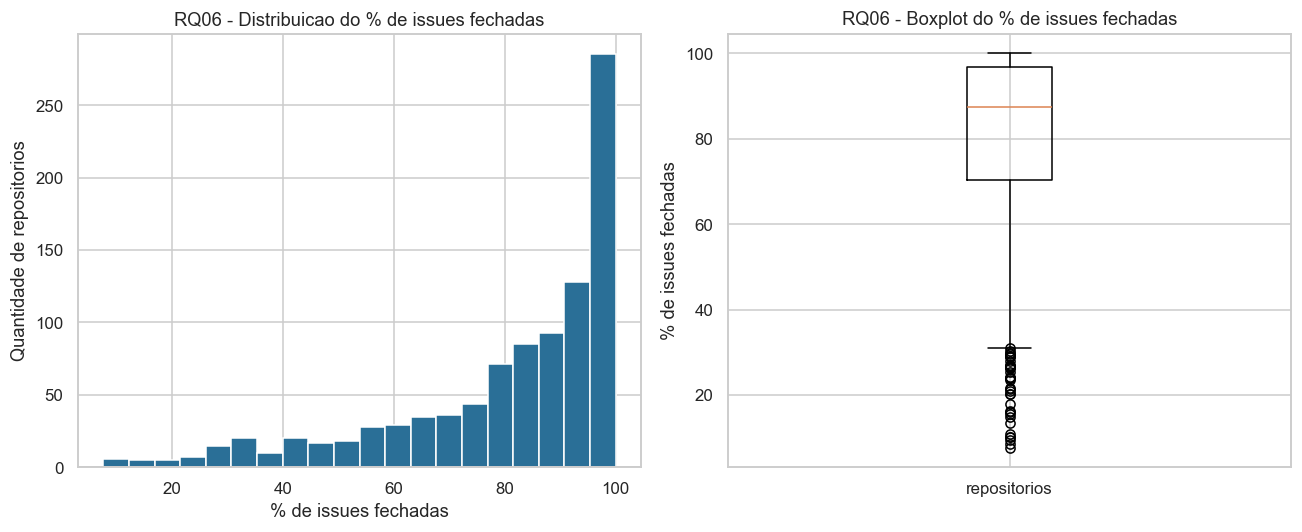

valores ausentes (issues_total=0): 43 (4.3%)
mediana: 87.6%
outliers -- 0% das issues fechadas: 0 (0.0%)
outliers -- 100% das issues fechadas: 28 (2.9%)


In [4]:
percentuais = df.loc[df["issues_total"] > 0, "percentual_issues_fechadas"] * 100
ausentes = len(df) - len(percentuais)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(percentuais, bins=20, color=COR_POPULAR, edgecolor="white")
axes[0].set_title("RQ06 - Distribuicao do % de issues fechadas")
axes[0].set_xlabel("% de issues fechadas")
axes[0].set_ylabel("Quantidade de repositorios")

axes[1].boxplot(percentuais, vert=True)
axes[1].set_title("RQ06 - Boxplot do % de issues fechadas")
axes[1].set_ylabel("% de issues fechadas")
axes[1].set_xticklabels(["repositorios"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "rq06_percentual_issues_fechadas.png")
plt.show()

zero = (percentuais == 0).sum()
cem = (percentuais == 100).sum()
print(f"valores ausentes (issues_total=0): {ausentes} ({ausentes / len(df) * 100:.1f}%)")
print(f"mediana: {percentuais.median():.1f}%")
print(f"outliers -- 0% das issues fechadas: {zero} ({zero / len(percentuais) * 100:.1f}%)")
print(f"outliers -- 100% das issues fechadas: {cem} ({cem / len(percentuais) * 100:.1f}%)")

## RQ07 - RQ02, RQ03 e RQ04 por linguagem

Repositorios sao agrupados em "Populares (Octoverse)" vs. "Outras" pela mesma
regra da RQ05, e comparados em PRs aceitas (RQ02), total de releases (RQ03) e
dias desde a ultima atualizacao (RQ04).

                       pull_requests_aceitas  total_releases  \
grupo_linguagem                                                
Outras                                 645.5            27.5   
Populares (Octoverse)                  920.0            52.0   

                       dias_desde_ultima_atualizacao  
grupo_linguagem                                       
Outras                                           0.0  
Populares (Octoverse)                            0.0  


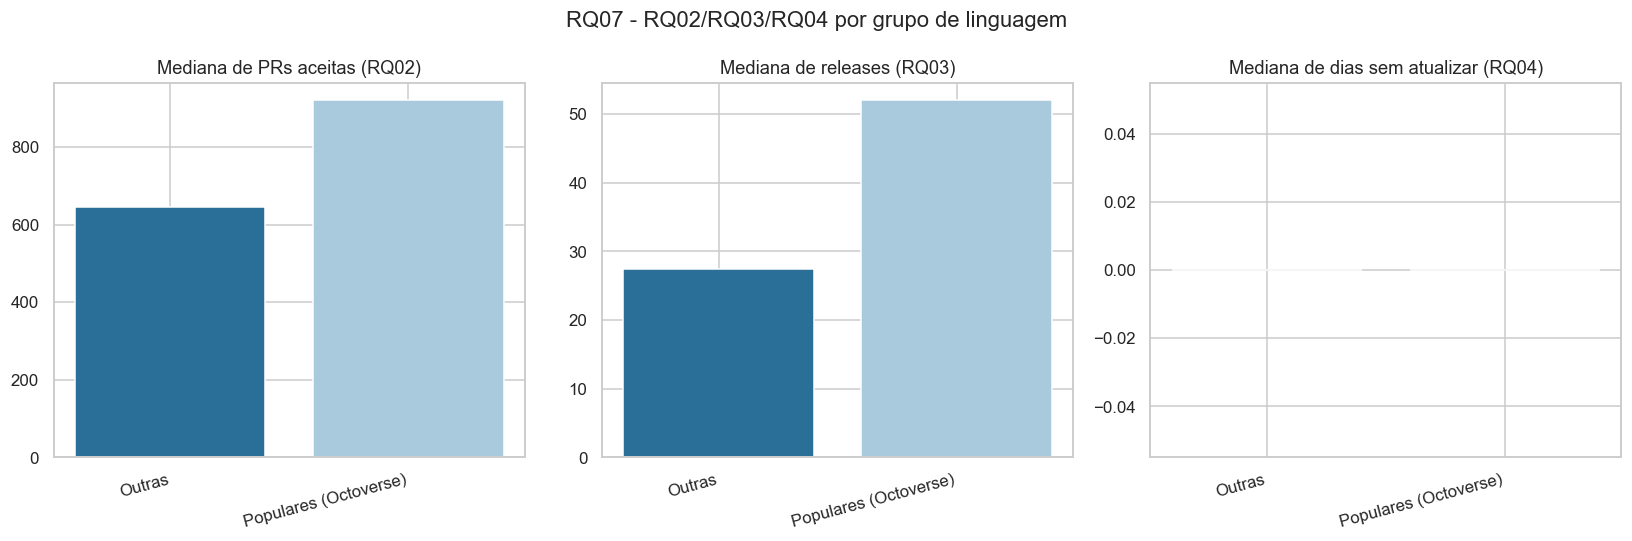

In [5]:
df["grupo_linguagem"] = df["linguagem_primaria"].apply(
    lambda ling: "Populares (Octoverse)" if ling in LINGUAGENS_POPULARES else "Outras"
)

medianas_grupo = df.groupby("grupo_linguagem")[
    ["pull_requests_aceitas", "total_releases", "dias_desde_ultima_atualizacao"]
].median()
print(medianas_grupo)

metricas = [
    ("pull_requests_aceitas", "Mediana de PRs aceitas (RQ02)"),
    ("total_releases", "Mediana de releases (RQ03)"),
    ("dias_desde_ultima_atualizacao", "Mediana de dias sem atualizar (RQ04)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (coluna, titulo) in zip(axes, metricas):
    ax.bar(medianas_grupo.index, medianas_grupo[coluna], color=[COR_POPULAR, COR_OUTRA])
    ax.set_title(titulo)
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

plt.suptitle("RQ07 - RQ02/RQ03/RQ04 por grupo de linguagem")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rq07_medianas_por_grupo.png")
plt.show()

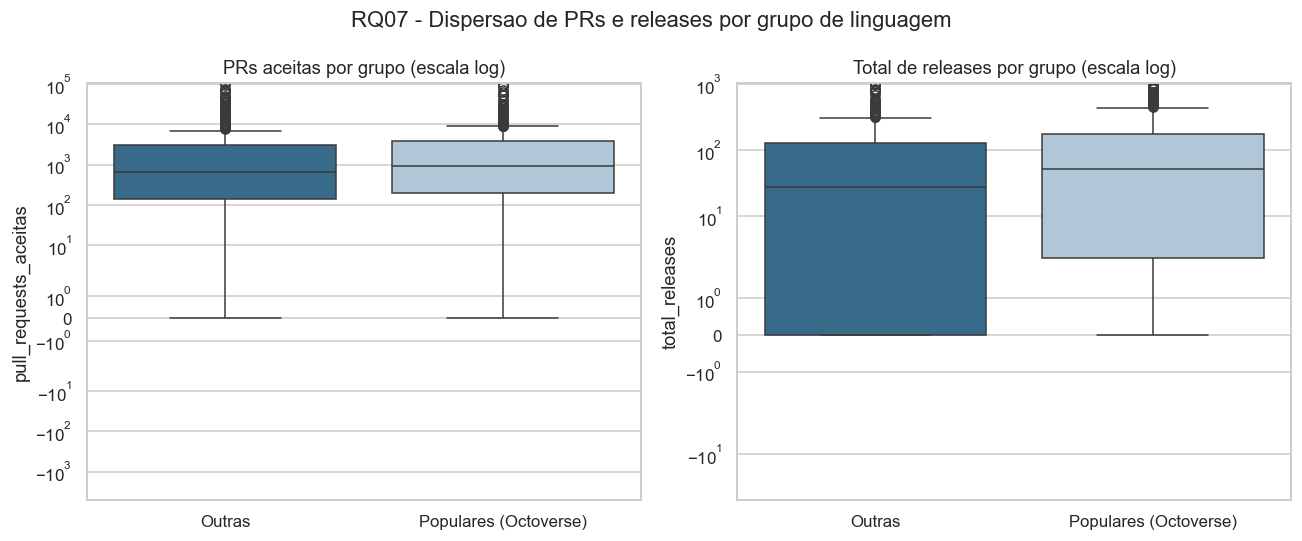

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df, x="grupo_linguagem", y="pull_requests_aceitas", ax=axes[0],
    hue="grupo_linguagem", palette=[COR_POPULAR, COR_OUTRA], legend=False,
)
axes[0].set_yscale("symlog")
axes[0].set_title("PRs aceitas por grupo (escala log)")
axes[0].set_xlabel("")

sns.boxplot(
    data=df, x="grupo_linguagem", y="total_releases", ax=axes[1],
    hue="grupo_linguagem", palette=[COR_POPULAR, COR_OUTRA], legend=False,
)
axes[1].set_yscale("symlog")
axes[1].set_title("Total de releases por grupo (escala log)")
axes[1].set_xlabel("")

plt.suptitle("RQ07 - Dispersao de PRs e releases por grupo de linguagem")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rq07_boxplots_por_grupo.png")
plt.show()

## RQ08 (bonus) - Licenca SPDX x popularidade/contribuicao

Repositorios sao classificados em `permissiva`, `copyleft`, `sem licenca`,
`nao mapeada (NOASSERTION)` ou `outra`, usando `classificar_licenca` do
`validate_sample.py`, e comparados por mediana de estrelas e de PRs aceitas.

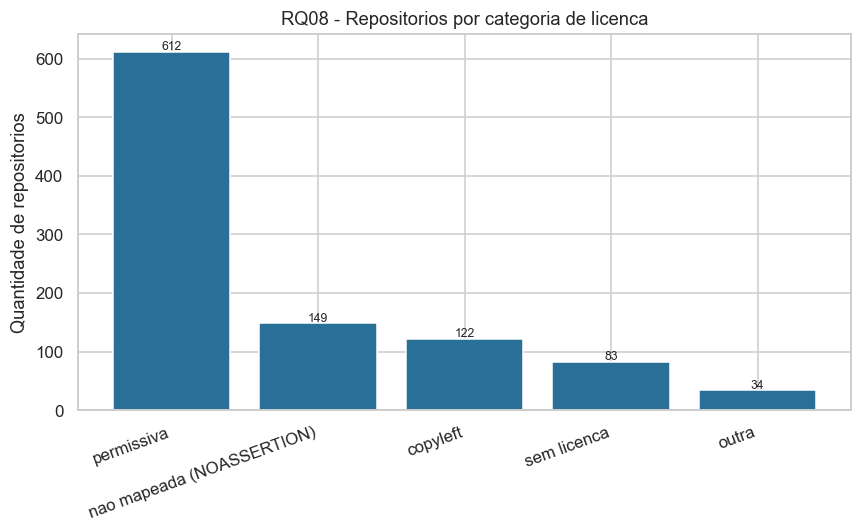

In [7]:
df["grupo_licenca"] = df["licenca"].apply(classificar_licenca)

contagem_licenca = df["grupo_licenca"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(contagem_licenca.index, contagem_licenca.values, color=COR_POPULAR)
ax.set_title("RQ08 - Repositorios por categoria de licenca")
ax.set_ylabel("Quantidade de repositorios")
for i, v in enumerate(contagem_licenca.values):
    ax.text(i, v + 3, str(v), ha="center", fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rq08_contagem_licencas.png")
plt.show()

                           estrelas  pull_requests_aceitas
grupo_licenca                                             
nao mapeada (NOASSERTION)   51375.0                 1228.0
copyleft                    45974.0                  963.0
permissiva                  49107.0                  913.5
outra                       49436.5                  430.5
sem licenca                 47009.0                  108.0


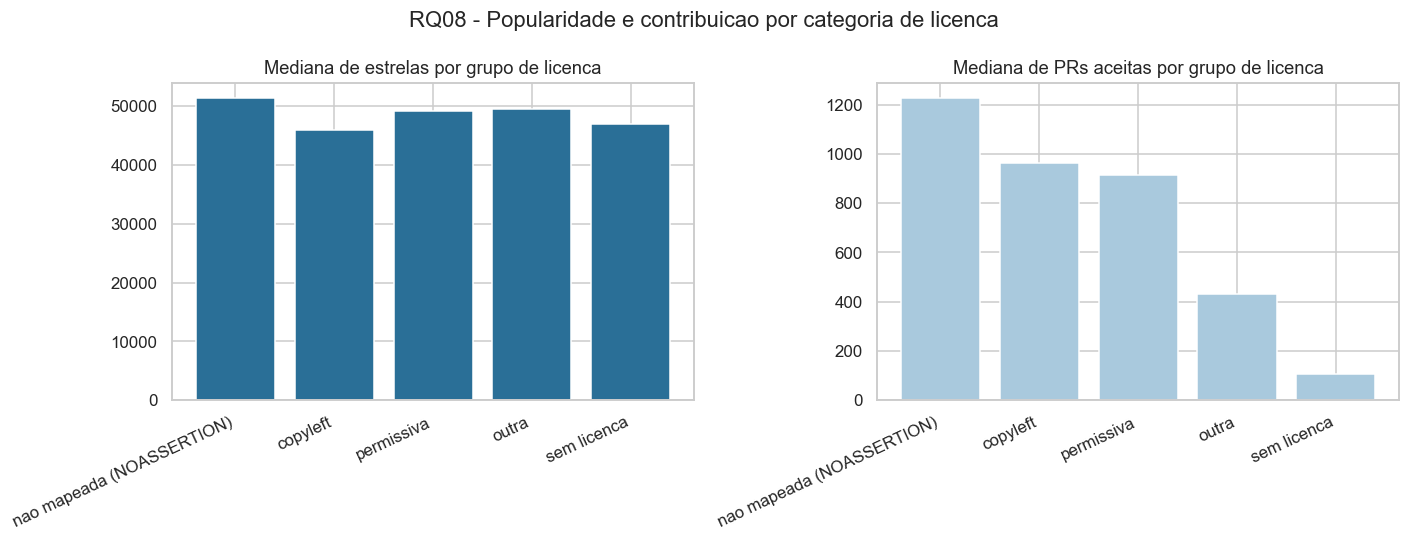

In [8]:
medianas_licenca = (
    df.groupby("grupo_licenca")[["estrelas", "pull_requests_aceitas"]]
    .median()
    .sort_values("pull_requests_aceitas", ascending=False)
)
print(medianas_licenca)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(medianas_licenca.index, medianas_licenca["estrelas"], color=COR_POPULAR)
axes[0].set_title("Mediana de estrelas por grupo de licenca")
plt.setp(axes[0].get_xticklabels(), rotation=25, ha="right")

axes[1].bar(medianas_licenca.index, medianas_licenca["pull_requests_aceitas"], color=COR_OUTRA)
axes[1].set_title("Mediana de PRs aceitas por grupo de licenca")
plt.setp(axes[1].get_xticklabels(), rotation=25, ha="right")

plt.suptitle("RQ08 - Popularidade e contribuicao por categoria de licenca")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rq08_medianas_por_licenca.png")
plt.show()

## Notas

- Todos os graficos sao salvos em `notebooks/figuras/` (PNG) para uso direto no
  `RELATORIO.md`.
- As mesmas constantes e regras de classificacao usadas em
  `src/validate_sample.py` sao reaproveitadas aqui, para que os numeros do
  relatorio e dos graficos nunca divirjam.
- Para reexecutar do zero: `jupyter nbconvert --to notebook --execute --inplace notebooks/analise_rq05_rq08.ipynb` a partir da raiz do `Laboratorio01`, ou abrir o notebook e rodar todas as celulas.